<style>
.note {padding: 12px 16px; border-left: 5px solid #2563eb; background: #eff6ff; margin: 10px 0;}
.warn {padding: 12px 16px; border-left: 5px solid #d97706; background: #fffbeb; margin: 10px 0;}
.fix  {padding: 12px 16px; border-left: 5px solid #dc2626; background: #fef2f2; margin: 10px 0;}
.exam {padding: 12px 16px; border-left: 5px solid #059669; background: #ecfdf5; margin: 10px 0;}
table {font-size: 95%;}
</style>

# 03 — Student’s t Distribution and t-Tests

### Inference for means when population variability is unknown

**Level:** beginner → advanced  
**Style:** short explanations, worked examples, formulas, runnable code, revision material

## What you will be able to do

- explain why the t distribution has heavier tails than the normal
- use degrees of freedom and the one-sample t statistic
- distinguish one-sample, paired, Student two-sample, and Welch tests
- report effect size and a confidence interval alongside the test

## Resource coverage

- Transcript lines 1657–2244: Student t distribution, degrees of freedom, t table, one-sample medication/IQ example
- Handwritten Student t resource: page 1 compares z and t formulas and introduces df = n−1
- Handwritten t-test resource: pages 1–2 show the IQ hypotheses, critical t values, statistic, and conclusion

<div class="note"><b>How to study this notebook:</b> Read once without memorising. Then rerun the code, solve each checkpoint without looking, and finish with the cheat sheet.</div>


## 1. Why Student’s t exists

For a mean, the ideal standardisation would be:

$$Z=\frac{\bar X-\mu}{\sigma/\sqrt n}$$

But $\sigma$ is usually unknown. We estimate it with the sample SD $s$:

$$T=\frac{\bar X-\mu}{s/\sqrt n}$$

Replacing $\sigma$ with $s$ adds uncertainty. The t distribution accounts for it with **heavier tails** than the standard normal.

Properties:

- symmetric around 0;
- bell-shaped;
- heavier tails for small degrees of freedom;
- approaches $N(0,1)$ as degrees of freedom increase.

Under a normal population and $H_0$:

$$T\sim t_{n-1}$$


## 2. Degrees of freedom

For a one-sample t-test:

$$df=n-1$$

Why lose one degree?

- Deviations from the sample mean must sum to zero.
- Once $n-1$ deviations are known, the last is forced.
- Estimating the mean uses one independent piece of information.

The lecture’s “three people, three chairs” analogy captures the idea of diminishing free choices. The statistical reason is the constraint imposed by estimating $\bar x$.


In [1]:
import math
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)


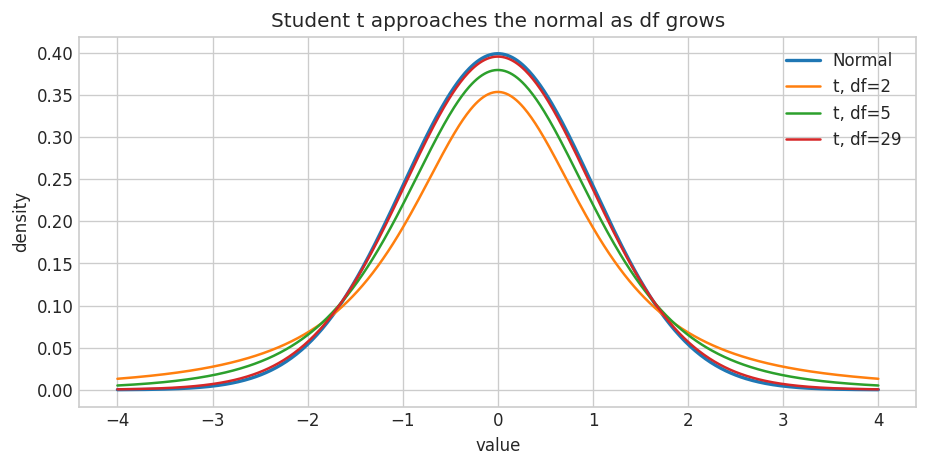

In [2]:
# Compare t densities with the standard normal.
x = np.linspace(-4, 4, 600)
plt.figure(figsize=(9, 4))
plt.plot(x, stats.norm.pdf(x), label='Normal', linewidth=2)
for df in [2, 5, 29]:
    plt.plot(x, stats.t.pdf(x, df), label=f't, df={df}')
plt.title('Student t approaches the normal as df grows')
plt.xlabel('value')
plt.ylabel('density')
plt.legend()
plt.show()


## 3. One-sample t-test

Question: does a population mean equal $\mu_0$ when $\sigma$ is unknown?

$$t=\frac{\bar x-\mu_0}{s/\sqrt n},\qquad df=n-1$$

Assumptions:

- observations are independent;
- data are a random/credible sample for the intended population;
- outcome is quantitative;
- population is approximately normal for a small sample, or the sample is large enough for robustness;
- no extreme outliers that dominate the mean and SD.

The hypotheses and tail work exactly like a z-test.


## 4. Lecture example: medication and IQ

Given:

- baseline claim $\mu_0=100$;
- sample after medication: $n=30$, $\bar x=140$, $s=20$;
- question asks for positive or negative change;
- $\alpha=0.05$.

Hypotheses:

$$H_0:\mu=100 \qquad H_a:\mu\ne100$$

Degrees of freedom: $df=29$.

Critical values: about $\pm2.045$.

Statistic:

$$t=\frac{140-100}{20/\sqrt{30}}=10.954$$

The statistic lies far into the right rejection tail. The two-sided p-value is about $8.0\times10^{-12}$, so reject $H_0$.

<div class="warn"><b>Interpretation boundary:</b> this proves neither that medication generally causes intelligence gains nor that the study is ethical/credible. A hypothesis test only answers the modelled question for the design and data supplied. Causal claims require randomisation, controls, blinding, and a defensible measurement process.</div>


In [3]:
mu0, n, xbar, s = 100, 30, 140, 20
t_obs = (xbar - mu0) / (s / math.sqrt(n))
df = n - 1
p_two = 2 * stats.t.sf(abs(t_obs), df)
t_crit = stats.t.ppf(0.975, df)
ci = (xbar - t_crit*s/math.sqrt(n), xbar + t_crit*s/math.sqrt(n))

print(f"t({df}) = {t_obs:.4f}")
print(f"two-sided p = {p_two:.3e}")
print(f"95% CI for mean = ({ci[0]:.3f}, {ci[1]:.3f})")


t(29) = 10.9545
two-sided p = 8.021e-12
95% CI for mean = (132.532, 147.468)


## 5. The main t-test family

| Test | Data structure | Null claim |
|---|---|---|
| One-sample t | one quantitative sample | $\mu=\mu_0$ |
| Paired t | same units twice or matched pairs | mean difference $\mu_d=0$ |
| Independent Student t | two independent groups, equal variances | $\mu_1-\mu_2=0$ |
| Welch t | two independent groups, variances may differ | $\mu_1-\mu_2=0$ |

### Paired t-test

1. Calculate each pair’s difference $d_i$.
2. Run a one-sample t-test on those differences.

$$t=\frac{\bar d}{s_d/\sqrt n},\qquad df=n-1$$

The unit of analysis is the **pair**, not the individual raw measurements.

### Independent groups

Welch’s t-test is usually a good default because it does not assume equal population variances. Student’s pooled test is efficient when equal variances are genuinely justified.


In [4]:
# Raw-data examples with SciPy
rng = np.random.default_rng(42)

# One sample
sample = rng.normal(loc=103, scale=12, size=30)
print('One sample:', stats.ttest_1samp(sample, popmean=100))

# Paired: before and after for the same people
before = np.array([8, 7, 9, 6, 8, 10, 7, 9])
after  = np.array([6, 6, 7, 5, 7,  8, 6, 7])
print('Paired:', stats.ttest_rel(before, after))

# Independent groups: Welch test (equal_var=False)
group_a = np.array([12, 11, 15, 14, 10, 16, 13])
group_b = np.array([9, 8, 13, 10, 7, 12, 11, 6])
print('Welch:', stats.ttest_ind(group_a, group_b, equal_var=False))


One sample: TtestResult(statistic=np.float64(1.8814327342771582), pvalue=np.float64(0.06998640986204878), df=np.int64(29))
Paired: TtestResult(statistic=np.float64(7.937253933193772), pvalue=np.float64(9.58459057192917e-05), df=np.int64(7))
Welch: TtestResult(statistic=np.float64(2.9405881764588204), pvalue=np.float64(0.011480967367097483), df=np.float64(12.995717344753746))


## 6. Confidence intervals and effect sizes

One-sample confidence interval:

$$\bar x\pm t_{1-\alpha/2,df}\frac{s}{\sqrt n}$$

One-sample Cohen’s $d$:

$$d=\frac{\bar x-\mu_0}{s}$$

For the lecture example, $d=(140-100)/20=2.0$, an enormous standardised difference. Context still matters more than labels like small/medium/large.

For paired data, use the SD of the differences. For independent groups, choose a denominator consistent with the design and clearly name the effect-size convention.


## 7. Robustness and alternatives

If data are strongly skewed or contaminated by outliers:

- inspect the data and collection process first;
- consider a scientifically defensible transformation;
- use bootstrap confidence intervals;
- consider Wilcoxon signed-rank for paired/one-sample location questions;
- consider Mann–Whitney for independent groups;
- remember that rank tests do not always test the same parameter as a t-test.

For large samples, the t-test is often robust to moderate non-normality. Independence and design quality remain non-negotiable.


# End-of-topic cheat sheet

| Item | Formula / idea |
|---|---|
| One-sample statistic | $t=(\bar x-\mu_0)/(s/\sqrt n)$ |
| df | $n-1$ |
| Why t? | $\sigma$ unknown; $s$ adds uncertainty |
| Small df | heavier tails, larger critical values |
| Paired test | one-sample t-test on pair differences |
| Two independent groups | Welch is usually the safer default |
| 95% CI | $\bar x\pm t_{.975,df}SE$ |
| Two-sided decision | reject if $|t|>t_{crit}$ or p $\le\alpha$ |
| As df grows | t approaches z |


# Revision questions and answers

**Q1. Why does the t distribution have heavier tails?**

<details><summary>Answer</summary>

Because replacing unknown $\sigma$ with the random estimate $s$ adds uncertainty, especially in small samples.

</details>

---

**Q2. What is df for a one-sample test with n = 30?**

<details><summary>Answer</summary>

$29$.

</details>

---

**Q3. What test compares the same people before and after treatment?**

<details><summary>Answer</summary>

A paired t-test, equivalently a one-sample t-test on the within-person differences.

</details>

---

**Q4. Why is Welch’s test often preferred for independent groups?**

<details><summary>Answer</summary>

It does not require equal population variances and performs well even when variances are equal.

</details>

---

**Q5. What are the IQ example’s hypotheses?**

<details><summary>Answer</summary>

$H_0:\mu=100$ versus $H_a:\mu\ne100$.

</details>

---

**Q6. What does t = 10.95 indicate?**

<details><summary>Answer</summary>

The sample mean is about 10.95 estimated standard errors above the null mean.

</details>

---

**Q7. Does a significant paired t-test prove every participant improved?**

<details><summary>Answer</summary>

No. It concerns the mean pair difference, not every individual response.

</details>

---

**Q8. What happens to t critical values as df increases?**

<details><summary>Answer</summary>

They decrease toward the corresponding standard-normal critical values.

</details>
